# **CONFIG**

In [1]:
from dataclasses import dataclass, field

@dataclass
class Settings:
    """
    All derived / computed fields are populated in __post_init__, so only the
    primary fields need to be set when instantiating Settings().

    Spectral arithmetic (with spectral_conv1D_kernel_size=4, stride=2, padding=1):
      Conv1d:          L_out = L_in // 2
      ConvTranspose1d: L_out = 2 * L_in
    With n=2 blocks and input_channels=108:
      Encoder:  108 → 54 → 27  (L);  channels  1 → 108 → 216
      Decoder:   27 → 54 → 108 (L);  channels 216 → 108 → 1
    """

    # ------------------------------------------------------------------
    # Input patch shape (output of slice.py)
    # ------------------------------------------------------------------
    input_height: int = 64
    input_width: int = 64
    input_channels: int = 108          # bands 7:115 of the 256-band IIRS cube

    # ------------------------------------------------------------------
    # Preprocessing knobs (used by utils/dataset/preprocess.py)
    # ------------------------------------------------------------------
    band_start: int = 7                # inclusive band index in the raw 256-band cube
    band_end: int = 115               # exclusive
    # Index *within the selected 108-band subset* that corresponds to ≈1500 nm.
    # Absolute index 48 - band_start = 48 - 7 = 41
    norm_band_idx: int = 41
    savgol_window: int = 7
    savgol_polyorder: int = 2

    # ------------------------------------------------------------------
    # Slicing knobs (used by utils/dataset/slice.py)
    # ------------------------------------------------------------------
    patch_size: int = 64
    patch_stride: int = 48                     # 25% overlap: stride = patch_size * 0.75
    split_ratios: tuple = (0.70, 0.15, 0.15)   # (train, valid, test)

    # ------------------------------------------------------------------
    # Data paths
    # ------------------------------------------------------------------
    data_processed_root: str = "/kaggle/input/datasets/utkarshchaudharycse/hsi-pi-vae-processed-dataset/processed"
    ckpt_dir: str = "/kaggle/working/ckpt/"

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------
    batch_size: int = 4
    num_workers: int = 4
    epochs: int = 20
    lr: int = 5e-3
    beta: int = 1e-3
    lambda_physics: int = 0.3

    # ------------------------------------------------------------------
    # Spatial branch
    # ------------------------------------------------------------------
    reduced_dims: int = 32            # Conv1D channel reduction per pixel spectrum
    latent_dim: int = 256             # spatial latent dim (after reparameterize chunk)
    n_2D_conv_blocks: int = 4        # 64 / 2^4 = 4 px spatial bottleneck
    conv2D_kernel_size: int = 3

    # Derived spatial (computed in __post_init__)
    conv_output_c: int = field(init=False)
    conv_output_h: int = field(init=False)
    conv_output_w: int = field(init=False)

    # ------------------------------------------------------------------
    # Spectral branch
    # ------------------------------------------------------------------
    spectral_n_1D_conv_blocks: int = 2
    # k=4 paired with stride=2, pad=1 gives exact halving/doubling:
    #   Conv1d:          L_out = L_in // 2
    #   ConvTranspose1d: L_out = 2 * L_in
    spectral_conv1D_kernel_size: int = 4
    spectral_latent_dim: int = 128    # per-pixel spectral latent (after reparameterize chunk)

    # Derived spectral (computed in __post_init__)
    spectral_linear_expansion_dim: int = field(init=False)
    spectral_transpose_c: int = field(init=False)
    spectral_transpose_l: int = field(init=False)

    def __post_init__(self):
        # ---- Spatial derived fields ----
        self.conv_output_c = self.reduced_dims * (2 ** self.n_2D_conv_blocks)
        self.conv_output_h = self.input_height // (2 ** self.n_2D_conv_blocks)
        self.conv_output_w = self.input_width // (2 ** self.n_2D_conv_blocks)

        # ---- Spectral derived fields ----
        # Encoder Conv1d final channel count:
        #   Block i goes from (in_c → out_c) where out_c doubles each step starting at input_channels.
        #   After n blocks: final channel = input_channels * 2^(n-1)
        self.spectral_transpose_c = self.input_channels * (
            2 ** (self.spectral_n_1D_conv_blocks - 1)
        )   # = 108 * 2 = 216

        # Encoder Conv1d final sequence length (halved each block):
        #   L_final = input_channels // 2^n
        self.spectral_transpose_l = self.input_channels // (
            2 ** self.spectral_n_1D_conv_blocks
        )   # = 108 // 4 = 27

        # Linear expansion size (what the decoder's linear layer must produce):
        self.spectral_linear_expansion_dim = (
            self.spectral_transpose_c * self.spectral_transpose_l
        )   # = 216 * 27 = 5832


settings = Settings()

# **Architecture**

In [2]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.1 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [3]:
!nvidia-smi

Tue Jun 23 03:45:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch
from torch import nn
from torch.nn import Conv1d, Conv2d, ConvTranspose1d, ConvTranspose2d

## **Spatial Branch**

In [5]:
class SpatialEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.pixel_reduction = Conv2d(
            in_channels=settings.input_channels,
            out_channels=settings.reduced_dims,
            kernel_size=1
        )

        in_c = settings.reduced_dims
        out_c = 2*in_c

        conv2d_layers = []
        for _ in range(settings.n_2D_conv_blocks):
            layer = Conv2d(
                in_channels=in_c,
                out_channels=out_c,
                kernel_size=settings.conv2D_kernel_size,
                stride=2,
                padding=1
            )
            conv2d_layers.append(layer)
            conv2d_layers.append(nn.ReLU())
            in_c=out_c
            out_c*=2

        self.conv2D_block = nn.Sequential(*conv2d_layers)

        self.flatten = nn.Flatten()

        # emit 2*latent_dim so reparameterize's chunk(2, dim=1) yields
        # (B, latent_dim) for mu and logvar respectively.
        self.linear = nn.LazyLinear(2 * settings.latent_dim)

    def forward(self, x):
        """
            x: (B, H, W, C)
            returns:
                (B, 2*latent_dim)  — mu and logvar concatenated along dim=1
                                     (caller should pass to reparameterize)
        """
        batch, h, w, c = x.shape
        assert h==settings.input_height, f"SPATIAL ENCODER: Mismatch in height. Expected: {settings.input_height} found: {h}."
        assert w==settings.input_width, f"SPATIAL ENCODER: Mismatch in width. Expected: {settings.input_width} found: {w}."
        assert c==settings.input_channels,  f"SPATIAL ENCODER: Mismatch in channels. Expected: {settings.input_channels} found: {c}."

        x = x.permute(0, 3, 1, 2)

        # Apply pixel-wise channel reduction natively
        x = self.pixel_reduction(x)
        # (B, reduced_dims, H, W)

        x = self.conv2D_block(x)
        # (B, conv_output_c, conv_output_h, conv_output_w)

        x = self.flatten(x)
        x = self.linear(x)
        # (B, 2*latent_dim)

        return x

In [6]:
class SpatialDecoder(nn.Module):
    def __init__(self, conv_output_c, conv_output_h, conv_output_w):
        super().__init__()
        self.conv_out_c = conv_output_c
        self.conv_out_h = conv_output_h
        self.conv_out_w = conv_output_w

        flatten = conv_output_c*conv_output_h*conv_output_w

        # FIX: in_features = latent_dim (not the previous hardcoded 256 which was
        # only correct when latent_dim happened to be 256, and breaks after the
        # encoder is fixed to emit 2*latent_dim).
        self.linear = nn.Linear(
            in_features=settings.latent_dim,
            out_features=flatten
        )

        in_c = conv_output_c

        layers = []
        for _ in range(settings.n_2D_conv_blocks):
            out_c = in_c // 2
            layer = nn.ConvTranspose2d(
                    in_channels=in_c,
                    out_channels=out_c,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                )
            
            layers.append(layer)
            layers.append(nn.ReLU())

            in_c = out_c
        
        self.transposeconv2D_block = nn.Sequential(*layers)

        self.pixel_expansion = Conv2d(
            in_channels=settings.reduced_dims,
            out_channels=settings.input_channels,
            kernel_size=1
        )
    
    def forward(self, z):
        """
        z: (B, 256)
        returns:
            (B, H, W, Bands)
        """

        B = z.shape[0]

        x = self.linear(z)

        x = x.view(
            B,
            self.conv_out_c,
            self.conv_out_h,
            self.conv_out_w,
        )

        x = self.transposeconv2D_block(x)
        # (B, reduced_dim, H, W)
        
        assert x.shape[1] == settings.reduced_dims, f"SPATIAL DECODER: Mismatch in channels. Expected reduced_dim={settings.reduced_dims}, found {x.shape[1]}"
        assert x.shape[2] == settings.input_height, f"SPATIAL DECODER: Mismatch in height. Expected height={settings.input_height}, found {x.shape[2]}"
        assert x.shape[3] == settings.input_width, f"SPATIAL DECODER: Mismatch in width. Expected width={settings.input_width}, found {x.shape[3]}"

        # Apply pixel-wise channel expansion natively
        x = self.pixel_expansion(x)
        # (B, input_channels, H, W)

        # Permute back to standard channel-last format for the loss/fusion
        x = x.permute(0, 2, 3, 1)
        # (B, H, W, C)
        
        return x

In [7]:
class SpatialEncoderDecoder(nn.Module):
    def __init__(self, conv_output_c, conv_output_h, conv_output_w,):
        super().__init__()

        self.encoder = SpatialEncoder()

        self.decoder = SpatialDecoder(
            conv_output_c=conv_output_c,
            conv_output_h=conv_output_h,
            conv_output_w=conv_output_w,
        )

    @staticmethod
    def reparameterize(z_flat):
        """
        Split encoder output into mu/logvar and sample z via the
        reparameterization trick.

        Args:
            z_flat : (B, 2*latent_dim) — raw encoder output

        Returns:
            z      : (B, latent_dim) — sampled latent
            mu     : (B, latent_dim)
            logvar : (B, latent_dim)
        """
        mu, logvar = torch.chunk(z_flat, 2, dim=1)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar

    def forward(self, x):
        """
        x: (B, H, W, C)
        returns:
            z             : (B, latent_dim)   — sampled latent
            mu            : (B, latent_dim)
            logvar        : (B, latent_dim)
            reconstruction: (B, H, W, C)
        """
        z_flat = self.encoder(x)                         # (B, 2*latent_dim)
        z, mu, logvar = self.reparameterize(z_flat)      # (B, latent_dim) each
        reconstruction = self.decoder(z)                 # (B, H, W, C)

        return z, mu, logvar, reconstruction

## **Spectral Branch**

In [8]:
class SpectralEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        in_c = 1
        out_c = settings.input_channels

        layers = []
        for _ in range(settings.spectral_n_1D_conv_blocks):
            layer = Conv2d(
                in_channels=in_c,
                out_channels=out_c,
                kernel_size=(settings.spectral_conv1D_kernel_size, 1),
                stride=(2, 1),
                padding=(1, 0)
            )
            layers.append(layer)
            layers.append(nn.ReLU())
            in_c = out_c
            out_c *= 2
            
        self.conv1D_block = nn.Sequential(*layers)
        
        self.flatten = nn.Flatten()

        # emit 2*spectral_latent_dim so reparameterize's chunk(2, dim=1)
        # yields (B, spectral_latent_dim, H, W) for mu and logvar respectively.
        self.latent_proj = Conv2d(
            in_channels=settings.spectral_linear_expansion_dim,
            out_channels=2 * settings.spectral_latent_dim,
            kernel_size=1
        )

    def forward(self, x):
        """
        x: (B, H, W, C)
        returns:
            (B, 2*spectral_latent_dim, H, W)  — mu and logvar concatenated along the channel dim (dim=1). Caller should pass to reparameterize.
        """
        batch, h, w, c = x.shape
        assert h == settings.input_height, f"SPECTRAL ENCODER: Mismatch in height. Expected: {settings.input_height} found: {h}."
        assert w == settings.input_width, f"SPECTRAL ENCODER: Mismatch in width. Expected: {settings.input_width} found: {w}."
        assert c == settings.input_channels, f"SPECTRAL ENCODER: Mismatch in channels. Expected: {settings.input_channels} found: {c}."

        # (B, H, W, C) -> (B, C, H, W)
        x = x.permute(0, 3, 1, 2)
        
        # Reshape to (B, 1, C, H*W) to treat the spatial grid as the "width" of an image
        x = x.reshape(batch, 1, c, h * w)
        
        x = self.conv1D_block(x)
        # Output: (B, final_channels, final_sequence_length, H*W)
        
        # Flatten the channel and sequence dimensions together
        final_c = x.shape[1]
        final_l = x.shape[2]
        x = x.reshape(batch, final_c * final_l, h, w)
        
        # Pixel-wise projection to latent space
        x = self.latent_proj(x)
        # (B, 2*spectral_latent_dim, H, W)
        
        return x

In [9]:
class SpectralDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # FIX: in_features = spectral_latent_dim (the reparameterized z dim,
        # *not* 2x) because decoder receives the sampled z after chunk.
        self.latent_expand = Conv2d(
            in_channels=settings.spectral_latent_dim,
            out_channels=settings.spectral_linear_expansion_dim,
            kernel_size=1
        )

        self.trans_in_c = settings.spectral_transpose_c
        
        in_c = self.trans_in_c
        
        layers = []
        for i in range(settings.spectral_n_1D_conv_blocks):
            # The final layer must output a single channel (the reconstructed 1D sequence)
            is_last = i == (settings.spectral_n_1D_conv_blocks - 1)
            out_c = 1 if is_last else in_c // 2
            
            layer = ConvTranspose2d(
                in_channels=in_c,
                out_channels=out_c,
                kernel_size=(settings.spectral_conv1D_kernel_size, 1),
                stride=(2, 1),
                padding=(1, 0)
            )
            layers.append(layer)
            if not is_last:
                layers.append(nn.ReLU())
                
            in_c = out_c

        self.transpose_block = nn.Sequential(*layers)

    def forward(self, z):
        """
        z: (B, spectral_latent_dim, H, W)
        returns:
            (B, H, W, input_channels)
        """
        batch, c, h, w = z.shape
        assert c == settings.spectral_latent_dim, f"SPECTRAL DECODER: Mismatch in channels. Expected: {settings.spectral_latent_dim} found: {c}."
        assert h == settings.input_height, f"SPECTRAL DECODER: Mismatch in height. Expected: {settings.input_height} found: {h}."
        assert w == settings.input_width, f"SPECTRAL DECODER: Mismatch in width. Expected: {settings.input_width} found: {w}."

        x = self.latent_expand(z)
        
        # Reshape for sequence expansion: (B, trans_c, trans_l, H*W)
        x = x.reshape(batch, settings.spectral_transpose_c, settings.spectral_transpose_l, h * w)
        
        x = self.transpose_block(x)
        # Output: (B, 1, input_channels, H*W)
        
        # Clean up dimensions
        x = x.squeeze(1) # (B, input_channels, H*W)
        x = x.reshape(batch, settings.input_channels, h, w)
        x = x.permute(0, 2, 3, 1) # (B, H, W, input_channels)
        
        return x

In [10]:
class SpectralEncoderDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SpectralEncoder()
        self.decoder = SpectralDecoder()

    @staticmethod
    def reparameterize(z_map):
        """
        Split encoder output into mu/logvar and sample z via the
        reparameterization trick.

        Args:
            z_map : (B, 2*spectral_latent_dim, H, W) — raw encoder output

        Returns:
            z      : (B, spectral_latent_dim, H, W)
            mu     : (B, spectral_latent_dim, H, W)
            logvar : (B, spectral_latent_dim, H, W)
        """
        mu, logvar = torch.chunk(z_map, 2, dim=1)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar

    def forward(self, x):
        """
        x: (B, H, W, C)
        returns:
            z             : (B, spectral_latent_dim, H, W)
            mu            : (B, spectral_latent_dim, H, W)
            logvar        : (B, spectral_latent_dim, H, W)
            reconstruction: (B, H, W, input_channels)
        """
        z_map = self.encoder(x)                          # (B, 2*spectral_latent_dim, H, W)
        z, mu, logvar = self.reparameterize(z_map)       # (B, spectral_latent_dim, H, W)
        reconstruction = self.decoder(z)                 # (B, H, W, input_channels)

        return z, mu, logvar, reconstruction

# **Data Loader**

In [11]:
from pathlib import Path
from typing import List

import numpy as np

from torch import Tensor
from torch.utils.data import Dataset, DataLoader

In [12]:
class HSIPatchDataset(Dataset):
    """
    Iterable dataset over all `.npy` patch files for a given split.

    Args:
        processed_root : path to the root produced by slice.py (e.g. ``data/processed/``)
        split          : one of ``'train'``, ``'valid'``, ``'test'``
    """

    def __init__(self, processed_root: str, split: str):
        assert split in ("train", "valid", "test"), (
            f"split must be one of 'train', 'valid', 'test'; got '{split}'"
        )

        root = Path(processed_root)

        # Collect all patches across all observation sub-folders for the split
        self.patch_files: List[Path] = sorted(root.glob(f"**/{split}/*.npy"))

    def __len__(self) -> int:
        return len(self.patch_files)

    def __getitem__(self, idx: int) -> Tensor:
        """
        Returns:
            Tensor of shape (H, W, C) == (patch_size, patch_size, input_channels)
            dtype: float32
        """
        patch = np.load(self.patch_files[idx], mmap_mode='r').astype(np.float32)
        
        # Normalize dynamically on the fly
        patch_max = patch.max()
        if patch_max > 0:
            patch = patch / patch_max
            
        return torch.from_numpy(patch)

In [13]:
def build_dataloader(
    processed_root: str,
    split: str,
    batch_size: int = settings.batch_size,
    shuffle: bool = True,
    num_workers: int = settings.num_workers,
    pin_memory: bool = True,
) -> DataLoader:
    """
    Factory for the HSIPatchDataset.

    Args:
        processed_root : path to data/processed/
        split          : 'train' | 'valid' | 'test'
        batch_size     : samples per batch
        shuffle        : True for training, False for evaluation
        num_workers    : DataLoader worker processes
        pin_memory     : speeds up CPU to GPU transfer when True

    Returns:
        torch.utils.data.DataLoader whose batches are (B, H, W, C) float32 tensors.
    """
    dataset = HSIPatchDataset(processed_root, split)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=(split == "train"),
    )
    return loader

# **Training Loop**

In [14]:
import math
import gc
import time
from pathlib import Path

import torch.optim as optim

## **Loss Functions**

### **Physics Guided Loss**

In [15]:
def spectral_angle_mapper_loss(y_true, y_pred):
    dot_product = torch.sum(y_true * y_pred, dim=-1)

    # Add epsilon BEFORE taking the square root to prevent NaN gradients at 0
    norm_true = torch.sqrt(torch.sum(y_true ** 2, dim=-1) + 1e-8)
    norm_pred = torch.sqrt(torch.sum(y_pred ** 2, dim=-1) + 1e-8)

    cos_sim = dot_product / (norm_true * norm_pred + 1e-8)
    cos_sim = torch.clamp(cos_sim, -1.0 + 1e-8, 1.0 - 1e-8)

    sam = torch.acos(cos_sim)
    return torch.mean(sam)

### **KL Loss**

In [16]:
def kl_divergence(mu, logvar):
    """ Standard KL Divergence pushing the manifold to N(0, I) """
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

### **Combined Loss**

In [17]:
def _compute_losses(model, x_batch, mse_loss_fn, beta, lambda_physics):
    """
    Run one forward pass and return all loss components.

    Returns:
        loss         : total scalar loss (backprop target)
        total_mse    : combined MSE term
        sam_loss     : SAM physics loss
        total_kld    : combined KL divergence
    """
    recon_final, recon_s, recon_p, mu_s, logvar_s, mu_p, logvar_p = model(x_batch)

    # 1. Reconstruction loss (MSE) — final + auxiliary branches
    mse_final    = mse_loss_fn(recon_final, x_batch)
    mse_spatial  = mse_loss_fn(recon_s, x_batch)
    mse_spectral = mse_loss_fn(recon_p, x_batch)
    total_mse = mse_final + 0.5 * mse_spatial + 0.5 * mse_spectral

    # 2. Physics prior loss (SAM) on the fused reconstruction
    sam_loss = spectral_angle_mapper_loss(x_batch, recon_final)

    # 3. KL Divergence — normalised by batch size
    B = x_batch.shape[0]
    kld_s = kl_divergence(mu_s, logvar_s) / B
    kld_p = kl_divergence(mu_p, logvar_p) / B
    total_kld = kld_s + kld_p

    # Total: ELBO + physics steering
    loss = total_mse + (beta * total_kld) + (lambda_physics * sam_loss)

    return loss, total_mse, sam_loss, total_kld, recon_final

## **Model**

In [18]:
class HSI_DualStream_PI_VAE(nn.Module):
    def __init__(self, conv_output_c, conv_output_h, conv_output_w):
        super().__init__()

        # Initialize isolated branches
        self.spatial_stream = SpatialEncoderDecoder(conv_output_c, conv_output_h, conv_output_w)
        self.spectral_stream = SpectralEncoderDecoder()

        # 1×1 linear fusion: (B, H, W, 2C) → (B, H, W, C)
        self.fusion_layer = nn.Linear(settings.input_channels * 2, settings.input_channels)

    def reparameterize(self, z_features):
        mu, logvar = torch.chunk(z_features, 2, dim=1)
        
        # Prevent logvar from exploding to infinity or shrinking to absolute zero
        logvar = torch.clamp(logvar, min=-30.0, max=20.0) 
        
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar

    def forward(self, x):
        # --- Spatial Stream ---
        spatial_features = self.spatial_stream.encoder(x)   # (B, 2*latent_dim)
        z_s, mu_s, logvar_s = self.reparameterize(spatial_features)
        recon_s = self.spatial_stream.decoder(z_s)          # (B, H, W, C)

        # --- Spectral Stream ---
        spectral_features = self.spectral_stream.encoder(x) # (B, 2*spectral_latent, H, W)
        z_p, mu_p, logvar_p = self.reparameterize(spectral_features)
        recon_p = self.spectral_stream.decoder(z_p)         # (B, H, W, C)

        # --- Late Fusion ---
        combined = torch.cat([recon_s, recon_p], dim=-1)    # (B, H, W, 2C)
        recon_final = torch.sigmoid(self.fusion_layer(combined))            # (B, H, W, C)

        return recon_final, recon_s, recon_p, mu_s, logvar_s, mu_p, logvar_p

In [19]:
def train_hsi_vae(
    model,
    dataloader,
    epochs,
    device,
    lr=1e-4,
    beta=0.001,
    lambda_physics=0.5,
    val_dataloader=None,
    ckpt_dir=None,
):
    """
    Main training loop.

    Args:
        model           : HSI_DualStream_PI_VAE instance
        dataloader      : DataLoader for the training split
        epochs          : number of training epochs
        device          : torch.device
        lr              : AdamW learning rate
        beta            : KL divergence weight
        lambda_physics  : SAM loss weight
        val_dataloader  : optional DataLoader for the validation split
        ckpt_dir        : if given, save checkpoints here
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse_loss_fn = nn.MSELoss()

    model.to(device)

    best_val_loss = math.inf
    ckpt_path = Path(ckpt_dir) if ckpt_dir else None
    if ckpt_path:
        ckpt_path.mkdir(parents=True, exist_ok=True)

    tic = time.time()
    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        train_loss = 0.0
        train_mse = train_sam = train_kld = 0.0

        for x_batch in dataloader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()

            loss, mse, sam, kld, _ = _compute_losses(
                model, x_batch, mse_loss_fn, beta, lambda_physics
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_mse  += mse.item()
            train_sam  += sam.item()
            train_kld  += kld.item()

        n_train = len(dataloader)
        train_loss /= n_train
        train_mse  /= n_train
        train_sam  /= n_train
        train_kld  /= n_train
        current_lr = optimizer.param_groups[0]["lr"]

        # ---- Validation ----
        val_loss = val_mse = val_sam = val_kld = 0.0
        if val_dataloader is not None:
            model.eval()
            with torch.no_grad():
                for x_val in val_dataloader:
                    x_val = x_val.to(device)
                    vloss, vmse, vsam, vkld, _ = _compute_losses(
                        model, x_val, mse_loss_fn, beta, lambda_physics
                    )
                    val_loss += vloss.item()
                    val_mse  += vmse.item()
                    val_sam  += vsam.item()
                    val_kld  += vkld.item()

            n_val = len(val_dataloader)
            val_loss /= n_val
            val_mse  /= n_val
            val_sam  /= n_val
            val_kld  /= n_val

        scheduler.step()

        # ---- Console logging ----
        toc = time.time()
        val_str = (
            f" | Val Loss: {val_loss:.4f} | Val MSE: {val_mse:.4f} "
            f"| Val SAM: {val_sam:.4f} | Val KLD: {val_kld:.4f}"
            if val_dataloader else ""
        )
        print(
            f"Time taken [{(toc-tic)/60} mins] | "
            f"Epoch [{epoch}/{epochs}] | "
            f"Loss: {train_loss:.4f} | MSE: {train_mse:.4f} | "
            f"SAM: {train_sam:.4f} | KLD: {train_kld:.4f} | "
            f"LR: {current_lr:.2e}"
            + val_str+"\n"
        )
        tic = toc

        # ---- Checkpoint saving ----
        if ckpt_path:
            # Save best model by validation loss (or train loss if no val loader)
            monitor = val_loss if val_dataloader else train_loss
            if monitor < best_val_loss:
                best_val_loss = monitor
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "loss": monitor,
                    },
                    ckpt_path / "best_model.pt",
                )

            # Periodic checkpoint every 10 epochs
            if epoch % 10 == 0:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "loss": train_loss,
                    },
                    ckpt_path / f"epoch_{epoch:04d}.pt",
                )

# **Train**

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}")
print(f"Number of GPUs available: {num_gpus}")

Using device: cuda
Number of GPUs available: 2


In [19]:
CONV_OUT_C = settings.conv_output_c
CONV_OUT_H = settings.conv_output_h
CONV_OUT_W = settings.conv_output_w

In [22]:
model = HSI_DualStream_PI_VAE(
    conv_output_c=CONV_OUT_C,
    conv_output_h=CONV_OUT_H,
    conv_output_w=CONV_OUT_W,
)

In [24]:
multi_gpu_batch_size = settings.batch_size * num_gpus
print(f"Adjusted batch size for multi-GPU: {multi_gpu_batch_size}")

train_loader = build_dataloader(
    settings.data_processed_root, "train",
    batch_size=multi_gpu_batch_size, 
    shuffle=True,
    num_workers=settings.num_workers,
)
val_loader = build_dataloader(
    settings.data_processed_root, "valid",
    batch_size=multi_gpu_batch_size,
    shuffle=False,
    num_workers=settings.num_workers,
)

model = model.to(device)

print("Initializing Lazy Modules with a dummy batch...")
dummy_batch = next(iter(train_loader)).to(device)

model.eval()
with torch.no_grad():
    _ = model(dummy_batch)
model.train()
print("Lazy Modules initialized.")

# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"Total Parameters: {total_params:,}")
# print(f"Trainable Parameters: {trainable_params:,}")

# 3. Wrap model in DataParallel AFTER weights exist
if num_gpus > 1:
    print(f"Activating DataParallel across {num_gpus} GPUs.")
    model = nn.DataParallel(model)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Adjusted batch size for multi-GPU: 8
Initializing Lazy Modules with a dummy batch...
Lazy Modules initialized.
Total Parameters: 13,117,585
Trainable Parameters: 13,117,585
Activating DataParallel across 2 GPUs.
Train batches: 974 | Val batches: 206


In [24]:
train_hsi_vae(
    model=model,
    dataloader=train_loader,
    epochs=settings.epochs,
    device=device,
    lr=settings.lr,
    beta=settings.beta,
    lambda_physics=settings.lambda_physics,
    val_dataloader=val_loader,
    ckpt_dir=settings.ckpt_dir,
)

Epoch [1/10] | Loss: 0.0287 | MSE: 0.0170 | SAM: 0.0375 | KLD: 0.4602 | LR: 1.00e-03 | Val Loss: 0.0163 | Val MSE: 0.0057 | Val SAM: 0.0340 | Val KLD: 0.4864

Epoch [2/10] | Loss: 0.0122 | MSE: 0.0036 | SAM: 0.0270 | KLD: 0.4705 | LR: 9.76e-04 | Val Loss: 0.0132 | Val MSE: 0.0043 | Val SAM: 0.0279 | Val KLD: 0.4745

Epoch [3/10] | Loss: 0.0097 | MSE: 0.0024 | SAM: 0.0229 | KLD: 0.4402 | LR: 9.05e-04 | Val Loss: 0.0120 | Val MSE: 0.0037 | Val SAM: 0.0264 | Val KLD: 0.3999

Epoch [4/10] | Loss: 0.0403 | MSE: 0.0032 | SAM: 0.0221 | KLD: 30.4441 | LR: 7.94e-04 | Val Loss: 0.0128 | Val MSE: 0.0038 | Val SAM: 0.0286 | Val KLD: 0.4893

Epoch [5/10] | Loss: 0.0082 | MSE: 0.0019 | SAM: 0.0195 | KLD: 0.4424 | LR: 6.55e-04 | Val Loss: 0.0098 | Val MSE: 0.0028 | Val SAM: 0.0220 | Val KLD: 0.4216

Epoch [6/10] | Loss: 0.0075 | MSE: 0.0017 | SAM: 0.0183 | KLD: 0.3864 | LR: 5.00e-04 | Val Loss: 0.0097 | Val MSE: 0.0025 | Val SAM: 0.0225 | Val KLD: 0.3797

Epoch [7/10] | Loss: 0.0071 | MSE: 0.0015 | S

# **Benchmarking against standard VAEs**

In [20]:
!pip install --no-cache-dir diffusers

In [27]:
from diffusers import AutoencoderKL

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## **HuggingFace VAE Adapter**

In [20]:
class Standard_HF_VAE_Baseline(nn.Module):
    def __init__(self, in_channels, block_out_channels, down_block_types, up_block_types, latent_channels):
        super().__init__()
        
        self.vae = AutoencoderKL(
            in_channels=3, # Temporary placeholder
            out_channels=3, # Temporary placeholder
            down_block_types=down_block_types,
            up_block_types=up_block_types,
            block_out_channels=block_out_channels,
            latent_channels=latent_channels
        )
        
        # Surgically replace the input and output convolutions to accept HSI data natively. This prevents the "unfair strawman" reviewer argument.
        first_conv_out = block_out_channels[0]
        self.vae.encoder.conv_in = nn.Conv2d(in_channels, first_conv_out, kernel_size=3, stride=1, padding=1)
        self.vae.decoder.conv_out = nn.Conv2d(first_conv_out, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        """
        x: (B, H, W, C)
        """
        # HF expects (B, C, H, W)
        x = x.permute(0, 3, 1, 2)
        
        posterior = self.vae.encode(x).latent_dist
        z = posterior.sample()
        
        recon = self.vae.decode(z).sample
        
        # Bound outputs to [0, 1] for fair MSE calculation
        recon = torch.sigmoid(recon)
        
        # Permute back to (B, H, W, C) for metric calculation
        recon = recon.permute(0, 2, 3, 1)
        
        return recon, posterior.mean, posterior.logvar

## **Ablation Function**

In [29]:
def run_phase_1_ablation(val_loader, device, num_batches=20):
    mse_loss_fn = nn.MSELoss()
    
    # 1. Initialize Your Model
    CONV_OUT_C = settings.reduced_dims * (2 ** settings.n_2D_conv_blocks)
    CONV_OUT_H = settings.input_height // (2 ** settings.n_2D_conv_blocks)
    CONV_OUT_W = settings.input_width // (2 ** settings.n_2D_conv_blocks)
    
    specsteer_vae = HSI_DualStream_PI_VAE(CONV_OUT_C, CONV_OUT_H, CONV_OUT_W).to(device)

    ckpt_path = '/kaggle/input/models/utkarshchaudharycse/hsi-vae-model-best-ckpt/pytorch/default/1/hsi_vae_model_best_ckpt.pt'
    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = checkpoint['model_state_dict']
    
    # Create a new state dict without the 'module.' prefix
    from collections import OrderedDict
    clean_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k  # remove 'module.'
        clean_state_dict[name] = v
        
    # Load the cleaned weights into the model
    specsteer_vae.load_state_dict(clean_state_dict)
    print("Successfully loaded SpecSteer weights!")
    
    # 2. Initialize HF Baselines (~13M params each)
    baseline_a = Standard_HF_VAE_Baseline(
        in_channels=settings.input_channels,
        block_out_channels=[128, 256],
        down_block_types=["DownEncoderBlock2D", "DownEncoderBlock2D"],
        up_block_types=["UpDecoderBlock2D", "UpDecoderBlock2D"],
        latent_channels=128
    ).to(device)

    baseline_b = Standard_HF_VAE_Baseline(
        in_channels=settings.input_channels,
        block_out_channels=[64, 128, 256, 512],
        down_block_types=["DownEncoderBlock2D", "DownEncoderBlock2D", "DownEncoderBlock2D", "DownEncoderBlock2D"],
        up_block_types=["UpDecoderBlock2D", "UpDecoderBlock2D", "UpDecoderBlock2D", "UpDecoderBlock2D"],
        latent_channels=64
    ).to(device)

    baseline_c = Standard_HF_VAE_Baseline(
        in_channels=settings.input_channels,
        block_out_channels=[64, 128, 256],
        down_block_types=["DownEncoderBlock2D", "DownEncoderBlock2D", "DownEncoderBlock2D"],
        up_block_types=["UpDecoderBlock2D", "UpDecoderBlock2D", "UpDecoderBlock2D"],
        latent_channels=128
    ).to(device)

    models = {
        "SpecSteer (Dual-Stream)": specsteer_vae,
        "Baseline A (Shallow 2-Stage)": baseline_a,
        "Baseline B (Deep 4-Stage)": baseline_b,
        "Baseline C (SD-Mini 3-Stage)": baseline_c
    }

    print("="*60)
    print("PHASE 1.1: ABLATION & PARAMETER COUNT")
    print("="*60)
    for name, model in models.items():
        print(f"{name:.<30} {count_parameters(model) / 1e6:.2f} M params")
    print("="*60)

    # 3. Evaluation Loop
    results = {name: {"MSE": 0.0, "SAM": 0.0, "KLD": 0.0} for name in models.keys()}
    
    for model in models.values():
        model.eval()

    print(f"Evaluating over {num_batches} random validation batches...")
    
    with torch.no_grad():
        for batch_idx, x_batch in enumerate(val_loader):
            if batch_idx >= num_batches:
                break
                
            x_batch = x_batch.to(device)
            B = x_batch.shape[0]

            for name, model in models.items():
                if name == "SpecSteer (Dual-Stream)":
                    recon, _, _, mu_s, logvar_s, mu_p, logvar_p = model(x_batch)
                    kld = (kl_divergence(mu_s, logvar_s) + kl_divergence(mu_p, logvar_p)) / B
                else:
                    recon, mu, logvar = model(x_batch)
                    kld = kl_divergence(mu, logvar) / B

                mse = mse_loss_fn(recon, x_batch)
                sam = spectral_angle_mapper_loss(x_batch, recon)

                results[name]["MSE"] += mse.item()
                results[name]["SAM"] += sam.item()
                results[name]["KLD"] += kld.item()

    # 4. Print Formal Results
    print("\nFINAL METRICS (Lower is Better)")
    print(f"{'Model Name':<30} | {'MSE':<10} | {'SAM (rad)':<10} | {'KLD':<10}")
    print("-" * 70)
    for name in models.keys():
        avg_mse = results[name]["MSE"] / num_batches
        avg_sam = results[name]["SAM"] / num_batches
        avg_kld = results[name]["KLD"] / num_batches
        print(f"{name:<30} | {avg_mse:<10.5f} | {avg_sam:<10.5f} | {avg_kld:<10.5f}")

In [27]:
multi_gpu_batch_size = settings.batch_size * num_gpus
print(f"Adjusted batch size for multi-GPU: {multi_gpu_batch_size}")

val_loader = build_dataloader(
    settings.data_processed_root, "valid",
    batch_size=multi_gpu_batch_size,
    shuffle=False,
    num_workers=settings.num_workers,
)

Adjusted batch size for multi-GPU: 8


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_phase_1_ablation(val_loader, device, num_batches=50)

Successfully loaded SpecSteer weights!
PHASE 1.1: ABLATION & PARAMETER COUNT
SpecSteer (Dual-Stream)....... 13.12 M params
Baseline A (Shallow 2-Stage).. 11.56 M params
Baseline B (Deep 4-Stage)..... 44.28 M params
Baseline C (SD-Mini 3-Stage).. 11.82 M params
Evaluating over 50 random validation batches...

FINAL METRICS (Lower is Better)
Model Name                     | MSE        | SAM (rad)  | KLD       
----------------------------------------------------------------------
SpecSteer (Dual-Stream)        | 0.00043    | 0.04929    | 0.12247   
Baseline A (Shallow 2-Stage)   | 0.04226    | 0.26938    | 0.00415   
Baseline B (Deep 4-Stage)      | 0.04225    | 0.26630    | 0.00369   
Baseline C (SD-Mini 3-Stage)   | 0.04236    | 0.26594    | 0.00339   


# **Training Baseline C - Ablation**

In [ ]:
import math
import gc
from pathlib import Path

from diffusers import AutoencoderKL

## **Architecture**

In [21]:
class Standard_HF_VAE_Baseline(nn.Module):
    def __init__(self, in_channels, block_out_channels, down_block_types, up_block_types, latent_channels):
        super().__init__()
        
        self.vae = AutoencoderKL(
            in_channels=3, 
            out_channels=3, 
            down_block_types=down_block_types,
            up_block_types=up_block_types,
            block_out_channels=block_out_channels,
            latent_channels=latent_channels
        )
        
        # Surgically replace the input and output convolutions
        first_conv_out = block_out_channels[0]
        self.vae.encoder.conv_in = nn.Conv2d(in_channels, first_conv_out, kernel_size=3, stride=1, padding=1)
        self.vae.decoder.conv_out = nn.Conv2d(first_conv_out, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        """
        x: (B, H, W, C)
        """
        x = x.permute(0, 3, 1, 2) # HF expects (B, C, H, W)
        
        posterior = self.vae.encode(x).latent_dist
        z = posterior.sample()
        
        recon = self.vae.decode(z).sample
        recon = torch.sigmoid(recon) # Bound to [0, 1]
        
        recon = recon.permute(0, 2, 3, 1) # Back to (B, H, W, C)
        
        return recon, posterior.mean, posterior.logvar

## **Loss Function**

In [ ]:
def _compute_baseline_losses(model, x_batch, mse_loss_fn, beta, lambda_physics):
    recon, mu, logvar = model(x_batch)
    
    mse = mse_loss_fn(recon, x_batch)
    sam = spectral_angle_mapper_loss(x_batch, recon)
    
    B = x_batch.shape[0]
    kld = kl_divergence(mu, logvar) / B
    
    # Unified Loss
    loss = mse + (beta * kld) + (lambda_physics * sam)
    
    return loss, mse, sam, kld

In [ ]:
def train_baseline_vae(model, train_loader, val_loader, epochs=14, device, ckpt_dir):
    lr = settings.lr
    beta = settings.beta
    lambda_physics = settings.lambda_physics
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse_loss_fn = nn.MSELoss()

    best_val_loss = math.inf
    ckpt_path = Path(ckpt_dir)
    ckpt_path.mkdir(parents=True, exist_ok=True)

    tic = time.time()
    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        train_loss = train_mse = train_sam = train_kld = 0.0

        for x_batch in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()

            loss, mse, sam, kld = _compute_baseline_losses(
                model, x_batch, mse_loss_fn, beta, lambda_physics
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_mse  += mse.item()
            train_sam  += sam.item()
            train_kld  += kld.item()

        n_train = len(train_loader)
        train_loss /= n_train
        train_mse  /= n_train
        train_sam  /= n_train
        train_kld  /= n_train
        current_lr = optimizer.param_groups[0]["lr"]

        # ---- Validation ----
        model.eval()
        val_loss = val_mse = val_sam = val_kld = 0.0
        
        with torch.no_grad():
            for x_val in val_loader:
                x_val = x_val.to(device)
                vloss, vmse, vsam, vkld = _compute_baseline_losses(
                    model, x_val, mse_loss_fn, beta, lambda_physics
                )
                val_loss += vloss.item()
                val_mse  += vmse.item()
                val_sam  += vsam.item()
                val_kld  += vkld.item()

        n_val = len(val_loader)
        val_loss /= n_val
        val_mse  /= n_val
        val_sam  /= n_val
        val_kld  /= n_val

        scheduler.step()

        # ---- Console logging ----
        toc = time.time()
        print(
            f"Time taken [{(toc-tic)/60} mins] | "
            f"Epoch [{epoch}/{epochs}] | "
            f"Loss: {train_loss:.4f} | MSE: {train_mse:.4f} | "
            f"SAM: {train_sam:.4f} | KLD: {train_kld:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"Val Loss: {val_loss:.4f} | Val MSE: {val_mse:.4f} | "
            f"Val SAM: {val_sam:.4f} | Val KLD: {val_kld:.4f}\n"
        )
        tic = toc

        # ---- Smart Checkpoint Saving ----
        # Extract base model state_dict safely, stripping 'module.' if DataParallel is active
        state_dict_to_save = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch,
                "model_state_dict": state_dict_to_save,
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": val_loss,
            }, ckpt_path / "baseline_c_best_model.pt")

        if epoch % 10 == 0:
            torch.save({
                "epoch": epoch,
                "model_state_dict": state_dict_to_save,
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": train_loss,
            }, ckpt_path / f"baseline_c_epoch_{epoch:04d}.pt")

        # ---- RAM Flush ----
        gc.collect()
        torch.cuda.empty_cache()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {num_gpus} GPUs on {device}")

# 1. DataLoaders
multi_gpu_batch_size = settings.batch_size * max(1, num_gpus)
train_loader = build_dataloader(
    settings.data_processed_root, "train",
    batch_size=multi_gpu_batch_size, 
    shuffle=True, num_workers=settings.num_workers
)
val_loader = build_dataloader(
    settings.data_processed_root, "valid",
    batch_size=multi_gpu_batch_size, 
    shuffle=False, num_workers=settings.num_workers
)

# 2. Initialize Baseline C (~11M Params)
baseline_c = Standard_HF_VAE_Baseline(
    in_channels=settings.input_channels,
    block_out_channels=[64, 128, 256],
    down_block_types=["DownEncoderBlock2D", "DownEncoderBlock2D", "DownEncoderBlock2D"],
    up_block_types=["UpDecoderBlock2D", "UpDecoderBlock2D", "UpDecoderBlock2D"],
    latent_channels=128
).to(device)

# 3. Enable DataParallel
if num_gpus > 1:
    baseline_c = nn.DataParallel(baseline_c)

# 4. Start Finetuning
print("Starting Baseline C Finetuning...")
train_baseline_vae(
    model=baseline_c,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=14,
    device=device,
    ckpt_dir="/kaggle/working/ckpt_baseline/"
)

# **Output visualisations**

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from collections import OrderedDict

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using {num_gpus} GPUs on {device}")

Using 2 GPUs on cuda


In [42]:
def visualize_model_comparisons(specsteer_model, baseline_model, dataloader, device, rgb_bands, pixel_idx):
    specsteer_model.eval()
    baseline_model.eval()
    
    # Grab a single batch
    batch = next(iter(dataloader))
    x_true = batch[:4].to(device)  # Ensure we only take exactly 4 samples
    
    with torch.no_grad():
        # SpecSteer Inference
        recon_specsteer, _, _, _, _, _, _ = specsteer_model(x_true)
        
        # Baseline Inference
        recon_baseline, _, _ = baseline_model(x_true)

    # Move to CPU and convert to numpy for plotting
    x_true = x_true.cpu().numpy()
    recon_specsteer = recon_specsteer.cpu().numpy()
    recon_baseline = recon_baseline.cpu().numpy()

    # Define bands for Pseudo-RGB visualization
    # (Adjust these indices based on the specific wavelengths you want to highlight)
    R_BAND, G_BAND, B_BAND = rgb_bands

    def get_pseudo_rgb(cube):
        """Extracts and normalizes 3 bands to create an RGB image."""
        rgb = np.stack([cube[:, :, R_BAND], cube[:, :, G_BAND], cube[:, :, B_BAND]], axis=-1)
        # Normalize to [0, 1] for matplotlib
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return rgb

    # =====================================================================
    # FIGURE 1: SPATIAL CONSISTENCY (Pseudo-Color RGB)
    # 4 Rows (Samples) x 3 Columns (Ground Truth, SpecSteer, Baseline)
    # =====================================================================
    fig_spatial, axes_sp = plt.subplots(4, 3, figsize=(12, 16))
    fig_spatial.suptitle("Spatial Consistency: Pseudo-Color RGB Reconstruction", fontsize=16, y=0.92)

    col_titles = ["Ground Truth", "SpecSteer (Ours)", "Baseline C (SD-Mini)"]

    for i in range(4):
        # Ground Truth
        axes_sp[i, 0].imshow(get_pseudo_rgb(x_true[i]))
        axes_sp[i, 0].axis('off')
        
        # SpecSteer
        axes_sp[i, 1].imshow(get_pseudo_rgb(recon_specsteer[i]))
        axes_sp[i, 1].axis('off')
        
        # Baseline
        axes_sp[i, 2].imshow(get_pseudo_rgb(recon_baseline[i]))
        axes_sp[i, 2].axis('off')

        # Add Column Titles only on the top row
        if i == 0:
            axes_sp[i, 0].set_title(col_titles[0], fontsize=14, pad=10)
            axes_sp[i, 1].set_title(col_titles[1], fontsize=14, pad=10)
            axes_sp[i, 2].set_title(col_titles[2], fontsize=14, pad=10)

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.savefig(f"/kaggle/working/{R_BAND}_{G_BAND}_{B_BAND}.png")
    plt.show()

    # =====================================================================
    # FIGURE 2: SPECTRAL CONSISTENCY (1D Absorption Curves)
    # 4 Rows (Samples) x 1 Column
    # =====================================================================
    fig_spectral, axes_spec = plt.subplots(4, 1, figsize=(10, 16))
    fig_spectral.suptitle("Spectral Consistency: 1D Absorption Signatures at Pixel (32, 32)", fontsize=16, y=0.92)

    # Pixel coordinate to sample the spectrum from
    px_y, px_x = pixel_idx
    wavelengths = np.arange(x_true.shape[-1]) # X-axis: Band indices 0 to 107

    for i in range(4):
        ax = axes_spec[i]
        
        # Extract the 1D arrays for the specific pixel
        true_curve = x_true[i, px_y, px_x, :]
        specsteer_curve = recon_specsteer[i, px_y, px_x, :]
        baseline_curve = recon_baseline[i, px_y, px_x, :]

        # Plot lines with requested colors
        ax.plot(wavelengths, true_curve, color='red', label='Ground Truth', linewidth=2.5, zorder=3)
        ax.plot(wavelengths, specsteer_curve, color='orange', label='SpecSteer (Ours)', linewidth=2.0, linestyle='--', zorder=2)
        ax.plot(wavelengths, baseline_curve, color='green', label='Baseline C', linewidth=1.5, linestyle=':', zorder=1)

        ax.set_ylabel("Reflectance", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only add legend and x-label on specific subplots to keep it clean
        if i == 0:
            ax.legend(loc='upper right', fontsize=12)
        if i == 3:
            ax.set_xlabel("Band Index", fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.savefig(f"/kaggle/working/{px_y}_{px_x}.png")
    plt.show()

In [25]:
# Load specsteer
specsteer_vae = HSI_DualStream_PI_VAE(CONV_OUT_C, CONV_OUT_H, CONV_OUT_W).to(device)

ckpt_path = '/kaggle/input/models/utkarshchaudharycse/hsi-vae-model-best-ckpt/pytorch/default/1/hsi_vae_model_best_ckpt.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
state_dict = checkpoint['model_state_dict']

from collections import OrderedDict
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k  # remove 'module.'
    clean_state_dict[name] = v
        
# Load the cleaned weights into the model
specsteer_vae.load_state_dict(clean_state_dict)
print("Successfully loaded SpecSteer weights!")

Successfully loaded SpecSteer weights!


In [28]:
# Load baseline C
baseline_c = Standard_HF_VAE_Baseline(
    in_channels=settings.input_channels,
    block_out_channels=[64, 128, 256],
    down_block_types=["DownEncoderBlock2D", "DownEncoderBlock2D", "DownEncoderBlock2D"],
    up_block_types=["UpDecoderBlock2D", "UpDecoderBlock2D", "UpDecoderBlock2D"],
    latent_channels=128
).to(device)

ckpt_path = '/kaggle/input/models/utkarshchaudharycse/sd-mini-finetuned-on-hsi-vae-loss/pytorch/default/1/baseline_c_best_model.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
state_dict = checkpoint['model_state_dict']

clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k  # remove 'module.'
    clean_state_dict[name] = v

baseline_c.load_state_dict(clean_state_dict)
print("Successfully loaded baseline_c weights!")

Successfully loaded baseline_c weights!


In [29]:
multi_gpu_batch_size = settings.batch_size * num_gpus
print(f"Adjusted batch size for multi-GPU: {multi_gpu_batch_size}")

val_loader = build_dataloader(
    settings.data_processed_root, "valid",
    batch_size=multi_gpu_batch_size,
    shuffle=False,
    num_workers=settings.num_workers,
)

Adjusted batch size for multi-GPU: 8


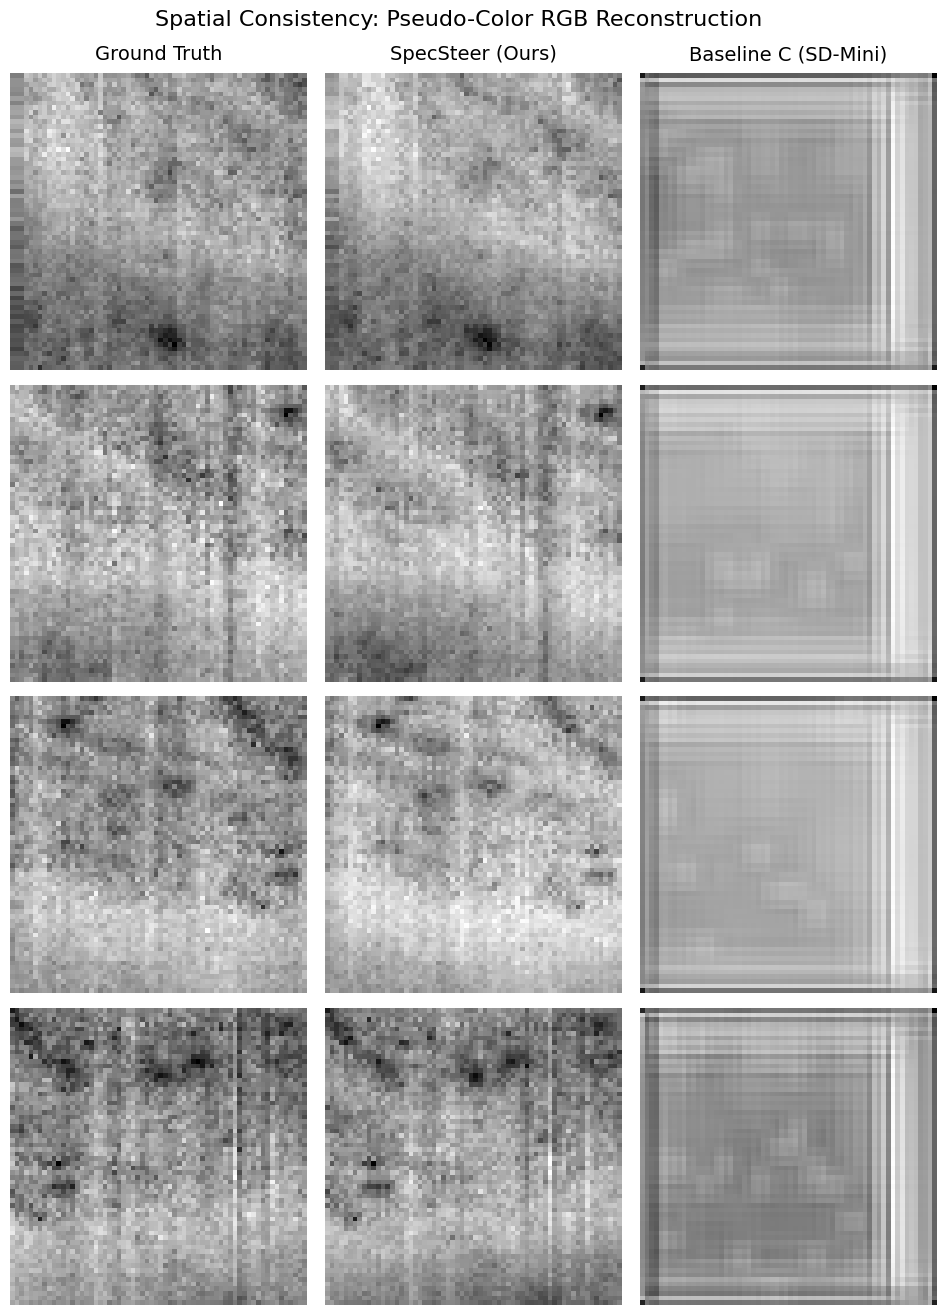

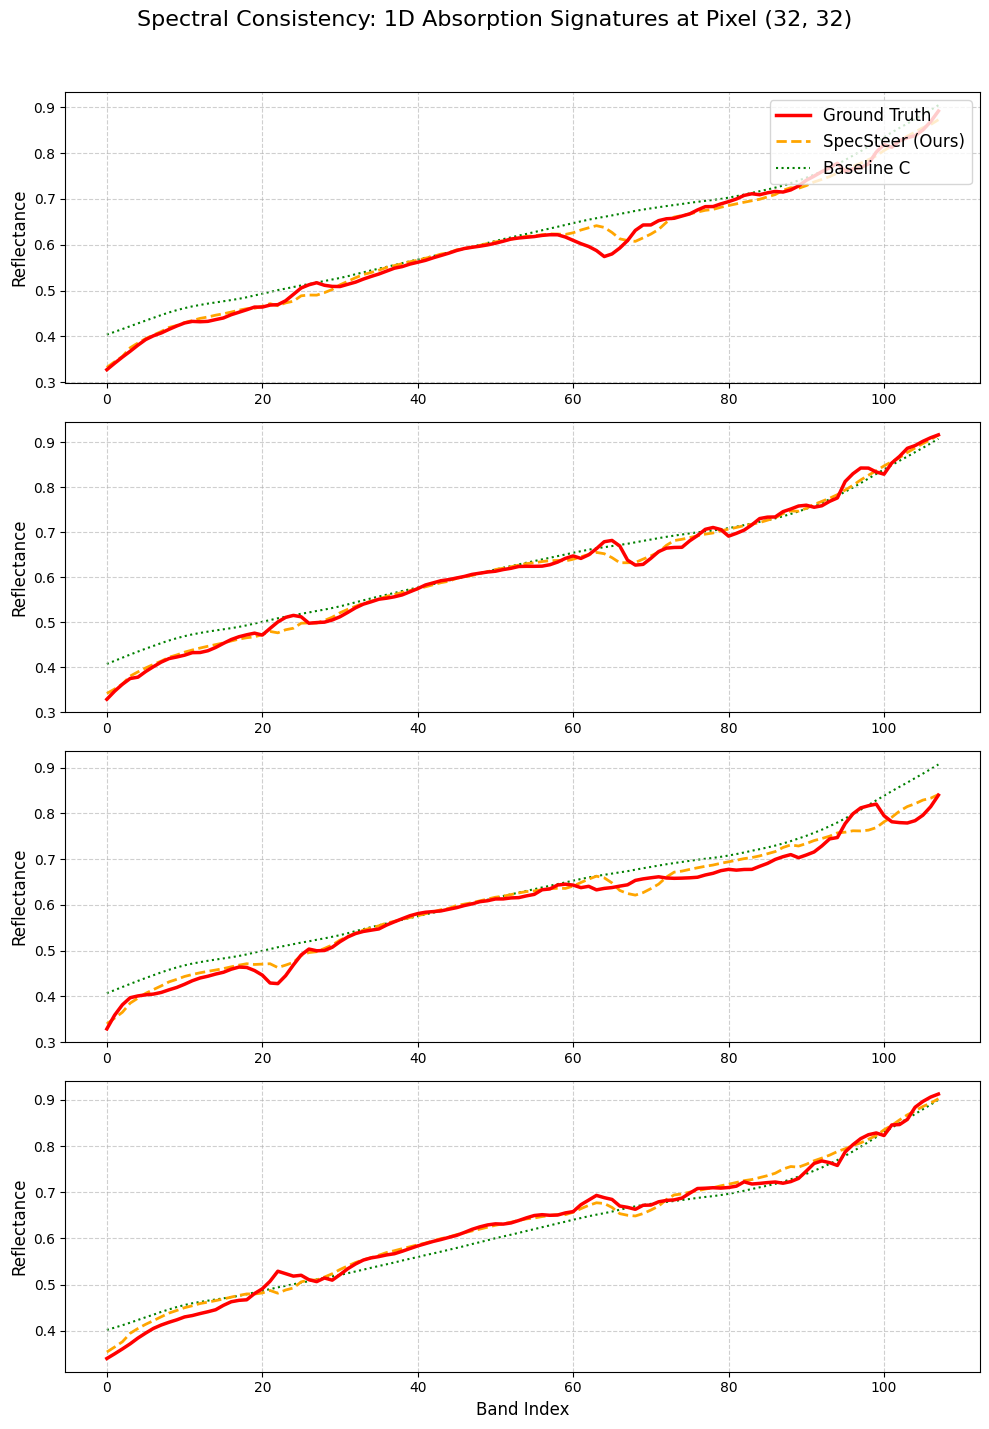

In [43]:
visualize_model_comparisons(specsteer_vae, baseline_c, val_loader, device, rgb_bands=(80,80,80), pixel_idx=(32,32))

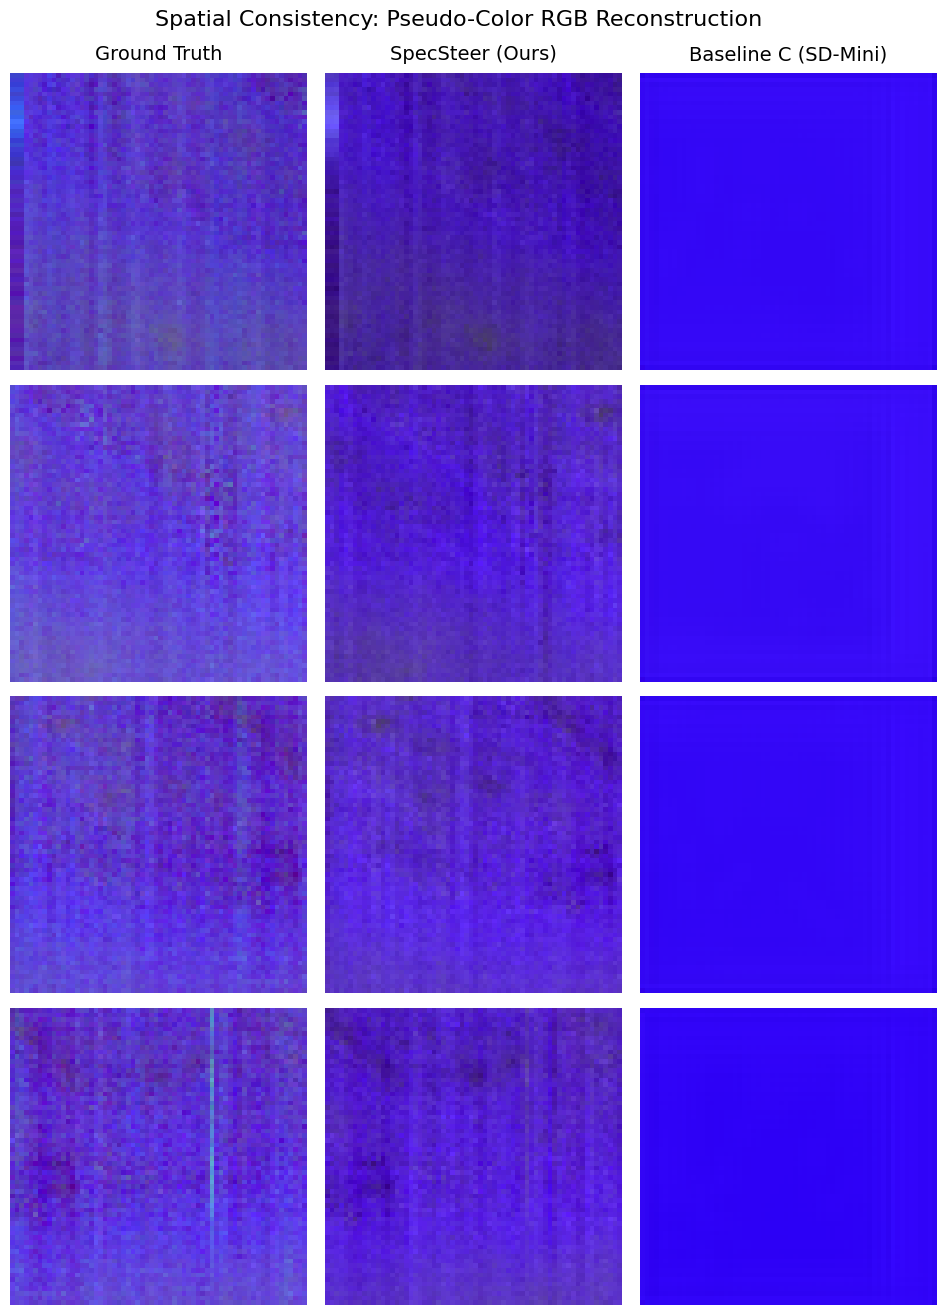

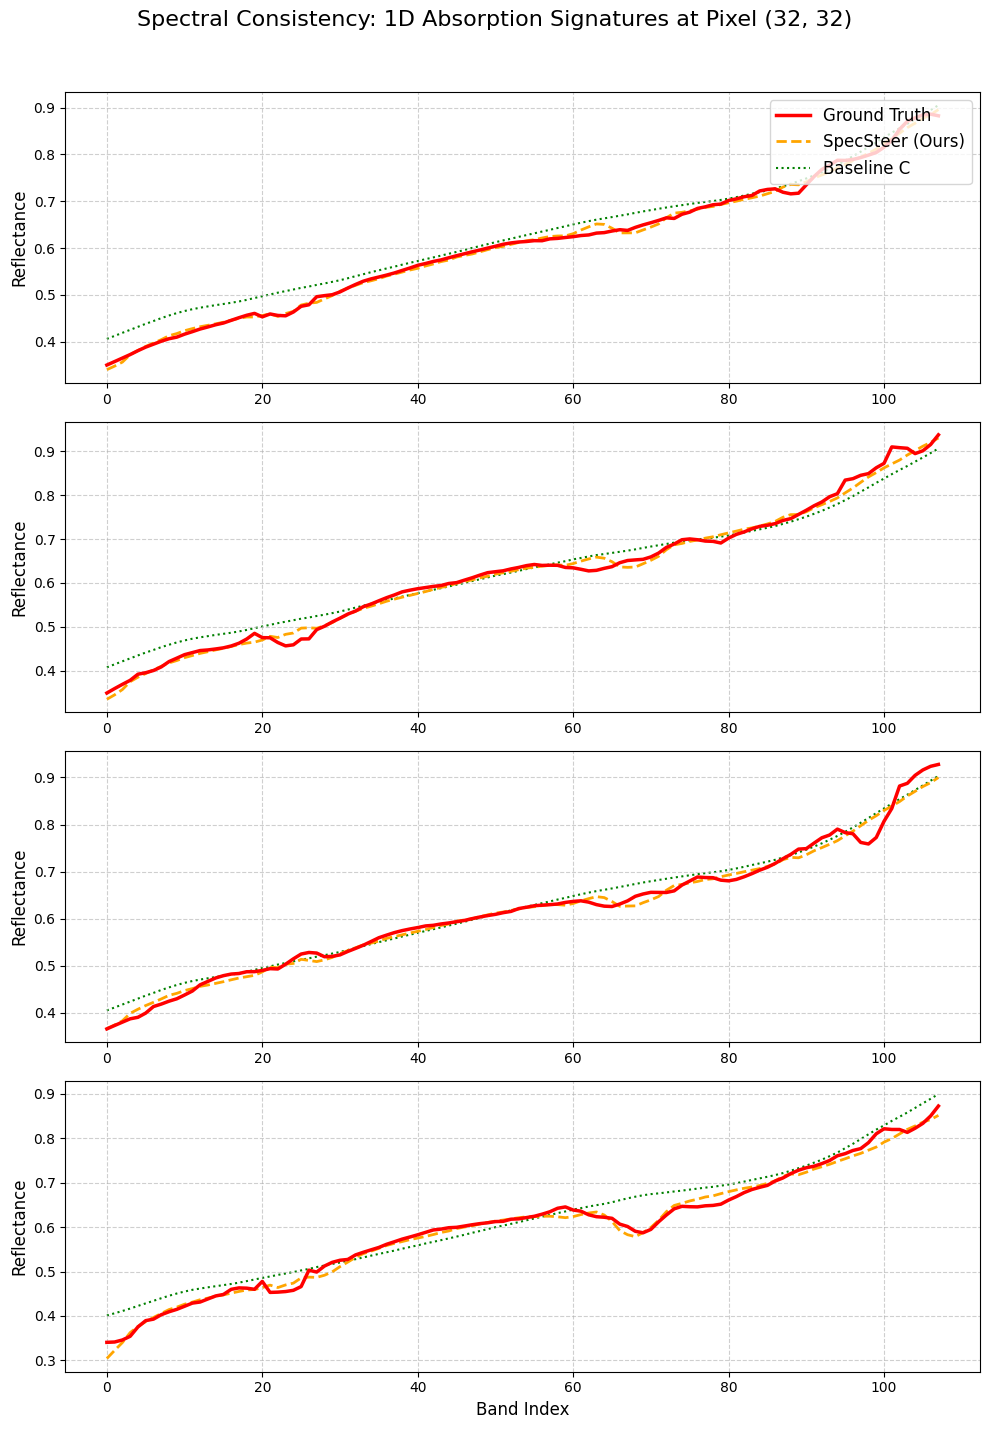

In [44]:
visualize_model_comparisons(specsteer_vae, baseline_c, val_loader, device, rgb_bands=(30,20,70), pixel_idx=(14,13))

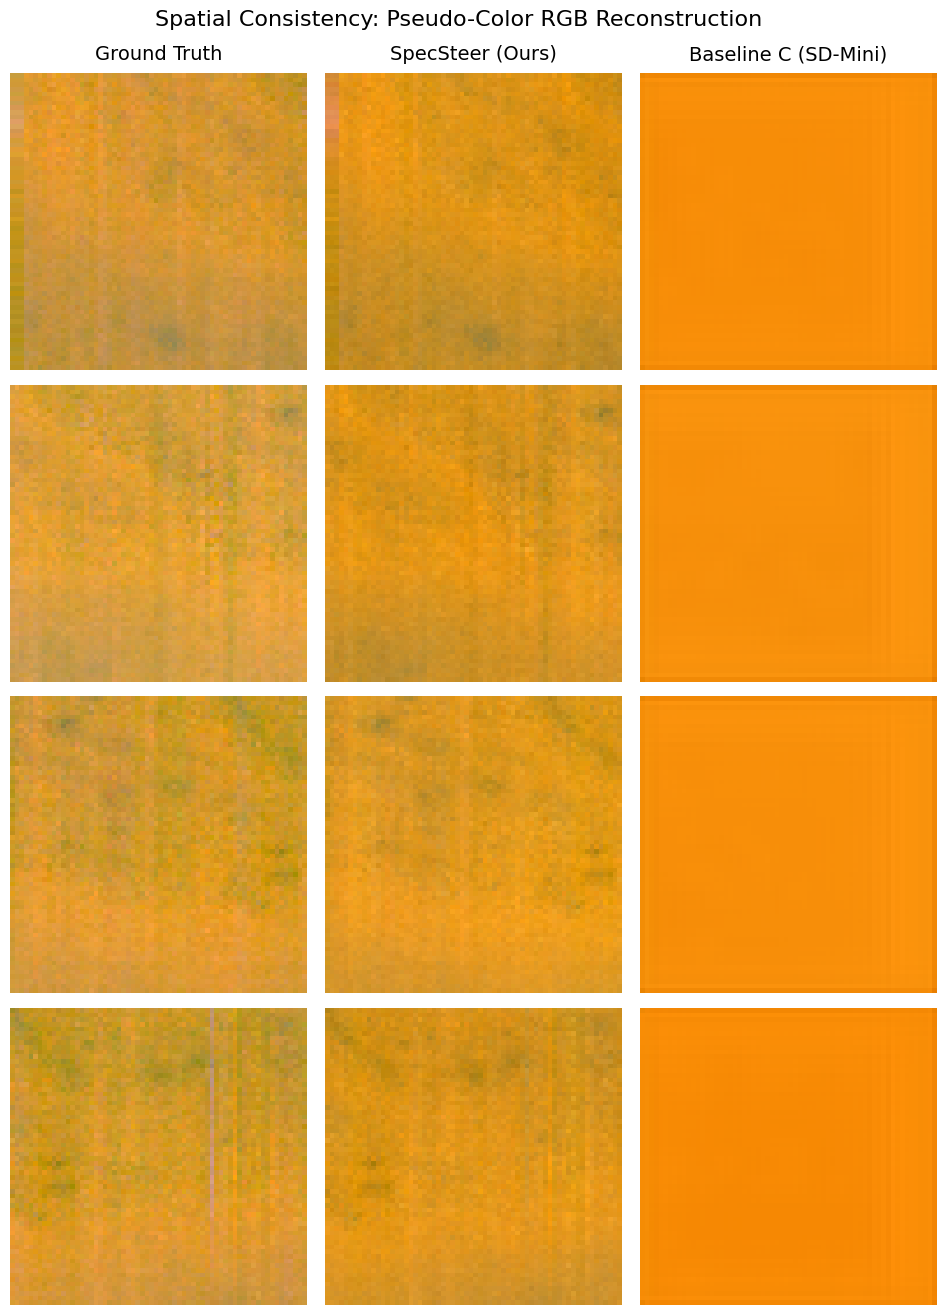

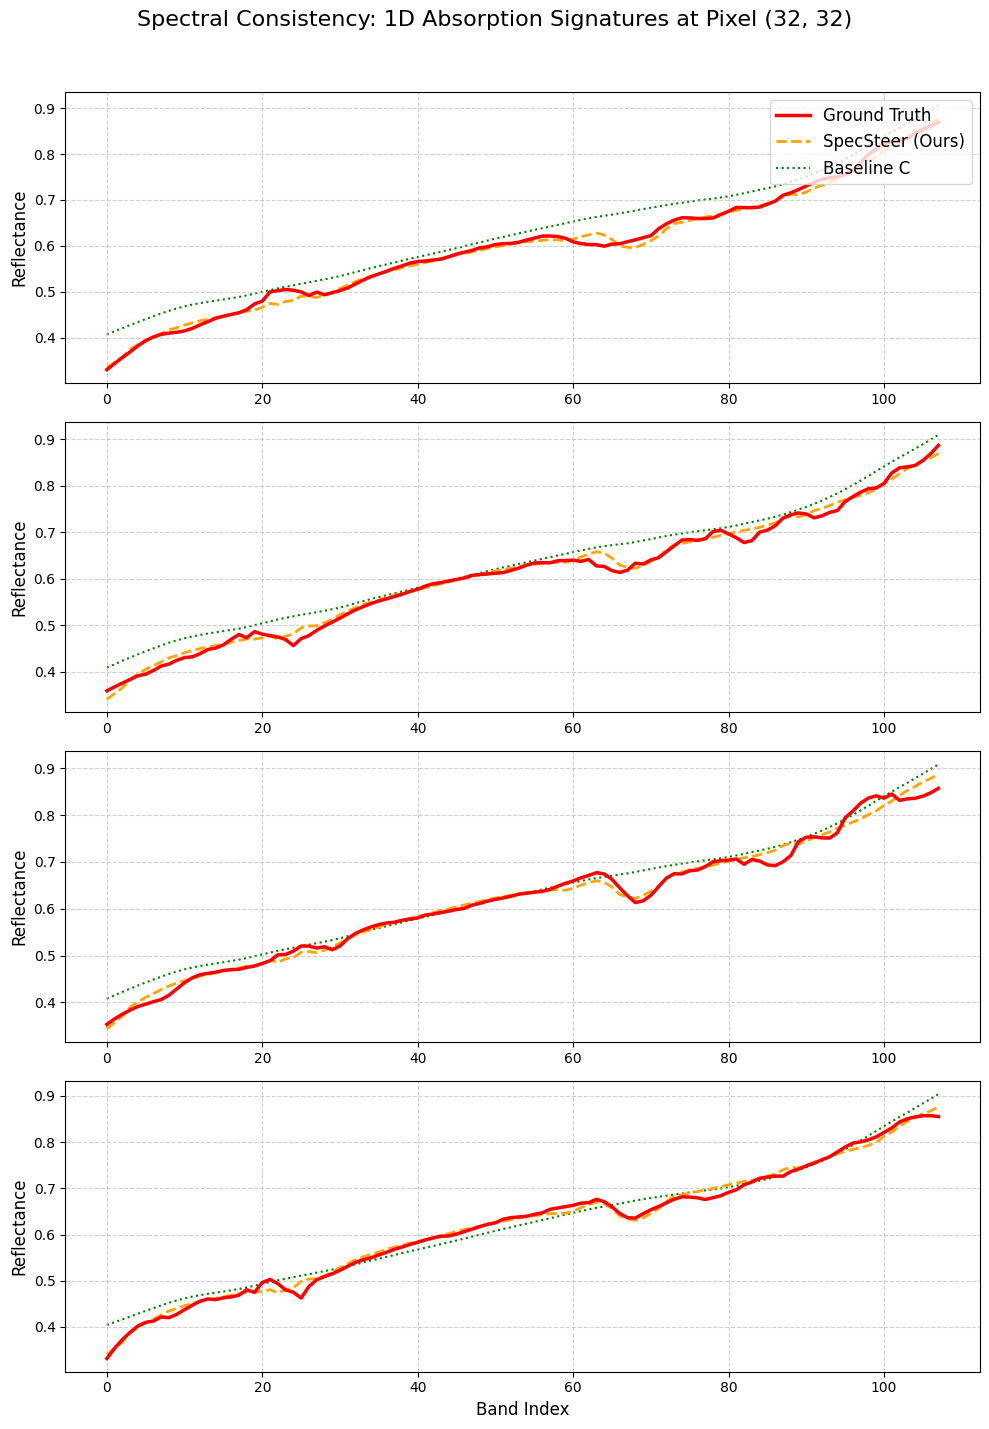

In [45]:
visualize_model_comparisons(specsteer_vae, baseline_c, val_loader, device, rgb_bands=(80,50,20), pixel_idx=(38,42))